# 👄 Yawn Model Training — RegNetY
Trains yawn/no_yawn classifier and saves `yawn_model.keras`

In [26]:
# ============================================================
# ✏️  EDIT IF NEEDED
# ============================================================
TRAIN_DIR  = 'dataset/Train'   # subfolders: No_yawn/ Yawn/
VAL_DIR    = 'dataset/Val'
TEST_DIR   = 'dataset/Test'
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 20
MODEL_OUT  = 'yawn_model.keras'
# ============================================================
print('Config ready')

Config ready


In [27]:
import os, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import RegNetX016
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print(f'TF version : {tf.__version__}')
print('✅ Imports ok')

TF version : 2.13.0
✅ Imports ok


In [28]:
# ── Data generators ──────────────────────────────────────────
# RegNet uses simple /255 normalization
def regnet_preprocess(img):
    return img / 255.0

train_gen = ImageDataGenerator(
    preprocessing_function=regnet_preprocess,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)
val_gen = ImageDataGenerator(preprocessing_function=regnet_preprocess)

train_ds = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True,
    classes=['No_yawn', 'Yawn']
)
val_ds = val_gen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False,
    classes=['No_yawn', 'Yawn']
)
test_ds = val_gen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False,
    classes=['No_yawn', 'Yawn']
)

CLASS_NAMES = list(train_ds.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes : {CLASS_NAMES}')
print(f'Train   : {train_ds.samples} images')
print(f'Val     : {val_ds.samples} images')
print(f'Test    : {test_ds.samples} images')

Found 4315 images belonging to 2 classes.
Found 882 images belonging to 2 classes.
Found 917 images belonging to 2 classes.
Classes : ['No_yawn', 'Yawn']
Train   : 4315 images
Val     : 882 images
Test    : 917 images


In [29]:
# ── Build RegNetX016 model ───────────────────────────────────
# RegNetX016 is built into tf.keras.applications (TF >= 2.8)
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

base = RegNetX016(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base.trainable = False
print(f'✅ RegNetX016 loaded — output shape: {base.output_shape}')

x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

✅ RegNetX016 loaded — output shape: (None, 7, 7, 912)


Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_9 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 regnetx016 (Functional)     (None, 7, 7, 912)         8320640   
                                                                 
 global_average_pooling2d_4  (None, 912)               0         
  (GlobalAveragePooling2D)                                       
                                                                 
 batch_normalization_4 (Bat  (None, 912)               3648      
 chNormalization)                                                
                                                                 
 dense_8 (Dense)             (None, 256)               233728    
                                                                 
 dropout_4 (Dropout)         (None, 256)               0   

In [30]:
# ── Phase 1: Train head only ──────────────────────────────────
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(
        'yawn_model_best.weights.h5',
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )
] 

history1 = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)

print('✅ Phase 1 done')

Epoch 1/20
135/135 [==============================] - ETA: 0s - loss: 0.4048 - accuracy: 0.8158
Epoch 1: val_loss improved from inf to 0.85656, saving model to yawn_model_best.weights.h5
135/135 [==============================] - 81s 595ms/step - loss: 0.4048 - accuracy: 0.8158 - val_loss: 0.8566 - val_accuracy: 0.5159 - lr: 0.0010
Epoch 2/20
135/135 [==============================] - ETA: 0s - loss: 0.3360 - accuracy: 0.8556
Epoch 2: val_loss improved from 0.85656 to 0.52281, saving model to yawn_model_best.weights.h5
135/135 [==============================] - 81s 600ms/step - loss: 0.3360 - accuracy: 0.8556 - val_loss: 0.5228 - val_accuracy: 0.9172 - lr: 0.0010
Epoch 3/20
135/135 [==============================] - ETA: 0s - loss: 0.3002 - accuracy: 0.8797
Epoch 3: val_loss improved from 0.52281 to 0.36042, saving model to yawn_model_best.weights.h5
135/135 [==============================] - 85s 632ms/step - loss: 0.3002 - accuracy: 0.8797 - val_loss: 0.3604 - val_accuracy: 0.9218 - l

In [31]:
# ── Phase 2: Fine-tune last 20 layers ────────────────────────
base.trainable = True
for layer in base.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_ds, epochs=10,
    validation_data=val_ds,
    callbacks=callbacks
)
print('✅ Phase 2 fine-tuning done')

Epoch 1/10
135/135 [==============================] - ETA: 0s - loss: 0.2093 - accuracy: 0.9226
Epoch 1: val_loss did not improve from 0.11235
135/135 [==============================] - 373s 3s/step - loss: 0.2093 - accuracy: 0.9226 - val_loss: 4.2992 - val_accuracy: 0.4853 - lr: 1.0000e-05
Epoch 2/10
135/135 [==============================] - ETA: 0s - loss: 0.2106 - accuracy: 0.9191
Epoch 2: val_loss did not improve from 0.11235
135/135 [==============================] - 368s 3s/step - loss: 0.2106 - accuracy: 0.9191 - val_loss: 3.6182 - val_accuracy: 0.4921 - lr: 1.0000e-05
Epoch 3/10
135/135 [==============================] - ETA: 0s - loss: 0.2032 - accuracy: 0.9233
Epoch 3: val_loss did not improve from 0.11235
135/135 [==============================] - 370s 3s/step - loss: 0.2032 - accuracy: 0.9233 - val_loss: 0.2635 - val_accuracy: 0.8923 - lr: 1.0000e-05
Epoch 4/10
135/135 [==============================] - ETA: 0s - loss: 0.2076 - accuracy: 0.9247
Epoch 4: val_loss did not im

In [32]:
# ── Evaluate on test set ─────────────────────────────────────
loss, acc = model.evaluate(test_ds, verbose=0)
print(f'Test Loss     : {loss:.4f}')
print(f'Test Accuracy : {acc:.2%}')

Test Loss     : 0.1376
Test Accuracy : 95.53%


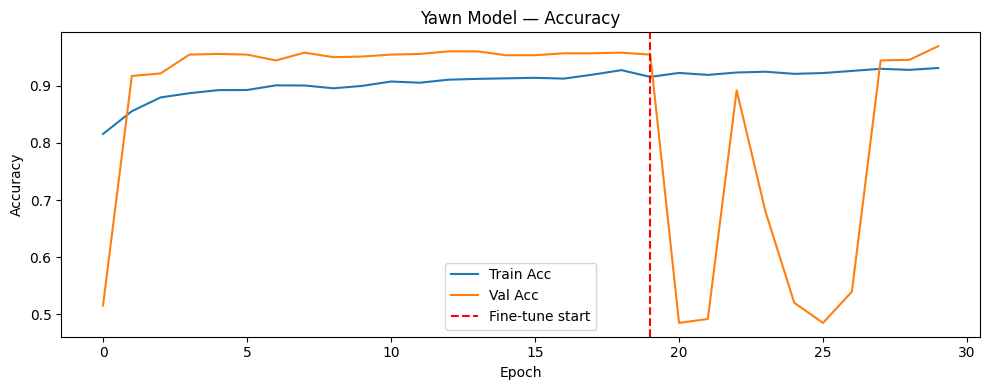

In [33]:
# ── Plot training curves ─────────────────────────────────────
all_acc = history1.history['accuracy'] + history2.history['accuracy']
all_val = history1.history['val_accuracy'] + history2.history['val_accuracy']

plt.figure(figsize=(10, 4))
plt.plot(all_acc, label='Train Acc')
plt.plot(all_val, label='Val Acc')
plt.axvline(len(history1.history['accuracy'])-1, color='red', linestyle='--', label='Fine-tune start')
plt.title('Yawn Model — Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.tight_layout()
plt.savefig('yawn_training_curve.png', dpi=120)
plt.show()

In [34]:
# ── Save final model ─────────────────────────────────────────
model.save(MODEL_OUT)
print(f'✅ Saved → {MODEL_OUT}')
print(f'   Input shape  : {model.input_shape}')
print(f'   Output shape : {model.output_shape}')
print(f'   Classes      : {CLASS_NAMES}')

✅ Saved → yawn_model.keras
   Input shape  : (None, 224, 224, 3)
   Output shape : (None, 2)
   Classes      : ['No_yawn', 'Yawn']


In [35]:
# import tensorflow as tf
# print([m for m in dir(tf.keras.applications) if m[0].isupper()])

In [36]:
import keras_cv
print(keras_cv.__version__)
print([m for m in dir(keras_cv.models) if 'Reg' in m])


Using TensorFlow backend
0.6.0
[]
